# Toy Hebbian Memory Model vs Transformer KV-Cache

---

## Purpose

This notebook implements a **simplified pedagogical proxy** of a Hebbian working-memory system for comparison with Transformer KV-cache memory.

**This notebook is NOT an implementation of the Brain Dragon Hatchling (BDH) architecture.**

Instead, it demonstrates the key educational idea:

- Transformer KV-cache memory grows linearly with sequence length.
- Hebbian memory occupies a fixed-size synaptic matrix that is updated in place.
- This toy model helps visualize bounded versus growing memory.

---

## Learning Goals

By the end of this notebook we will:

1. Build a fixed-size Hebbian memory.
2. Simulate token-by-token updates.
3. Observe how the synaptic matrix evolves.
4. Measure Frobenius norm growth.
5. Compare memory usage against a Transformer KV-cache.
6. Generate data later used by the interactive artifact.

---

## Repository Structure

```
src/
    model.py
    simulation.py
    evaluation.py
    utils.py

notebooks/
    toy_model.ipynb
    generate_precomputed.ipynb

artifact/
    precomputed/
```

---

## Disclaimer

The Hebbian update implemented here is intentionally simplified for educational purposes.

Whenever discussing BDH itself, refer to the original paper rather than this proxy implementation.

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Allow notebook to import from src/
ROOT = Path.cwd().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from model import (
    HebbianConfig,
    HebbianMemory,
    compare_memory,
    random_sparse_pattern,
)

from simulation import (
    SimulationConfig,
    simulate_sequence,
)

from evaluation import (
    full_evaluation,
)

In [3]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Allow notebook to import from src/
ROOT = Path.cwd().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from model import (
    HebbianConfig,
    HebbianMemory,
    compare_memory,
    random_sparse_pattern,
)

from simulation import (
    SimulationConfig,
    simulate_sequence,
)

from evaluation import (
    full_evaluation,
)

In [4]:
plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

In [5]:
# ----------------------------------------------------
# Create the Hebbian Memory Model
# ----------------------------------------------------

hebb_cfg = HebbianConfig(
    n_neurons=64,
    decay=0.05,
    learning_rate=0.10,
    sparsity=0.10
)

sim_cfg = SimulationConfig(
    n_tokens=500,
    random_seed=42,
    hidden_size=768,
    n_layers=12
)

memory = HebbianMemory(hebb_cfg)

print("Configuration")
print("----------------")
print(hebb_cfg)
print(sim_cfg)
print()

print(f"Synaptic matrix shape : {memory.W.shape}")
print(f"Memory size           : {memory.memory_bytes()/1024:.2f} KiB")

Configuration
----------------
HebbianConfig(n_neurons=64, decay=0.05, learning_rate=0.1, sparsity=0.1)
SimulationConfig(n_tokens=500, random_seed=42, hidden_size=768, n_layers=12)

Synaptic matrix shape : (64, 64)
Memory size           : 16.00 KiB


In [6]:
# ----------------------------------------------------
# Run token-by-token simulation
# ----------------------------------------------------

simulation = simulate_sequence(
    hebb_cfg,
    sim_cfg
)

frames = simulation["frames"]
norms = simulation["norms"]

print(f"Tokens simulated : {len(frames)}")
print(f"Final norm       : {norms[-1]:.3f}")

Tokens simulated : 500
Final norm       : 2.443


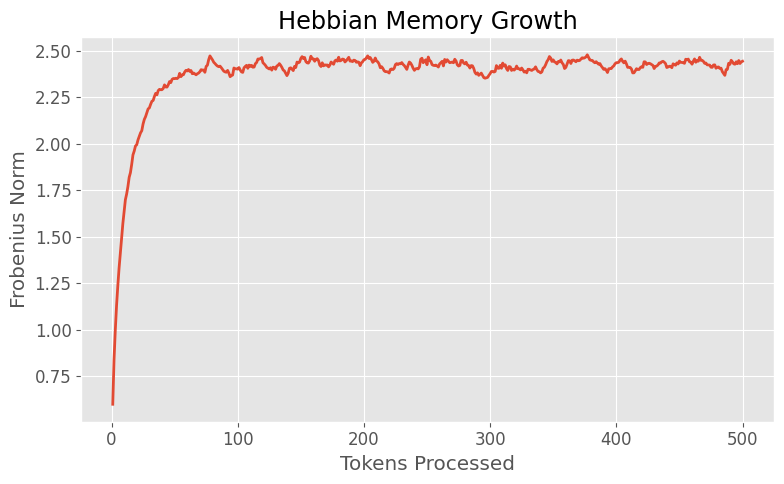

In [7]:
# ----------------------------------------------------
# Frobenius Norm Evolution
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(norms)+1),
    norms,
    linewidth=2
)

plt.xlabel("Tokens Processed")

plt.ylabel("Frobenius Norm")

plt.title("Hebbian Memory Growth")

plt.grid(True)

plt.tight_layout()

plt.show()

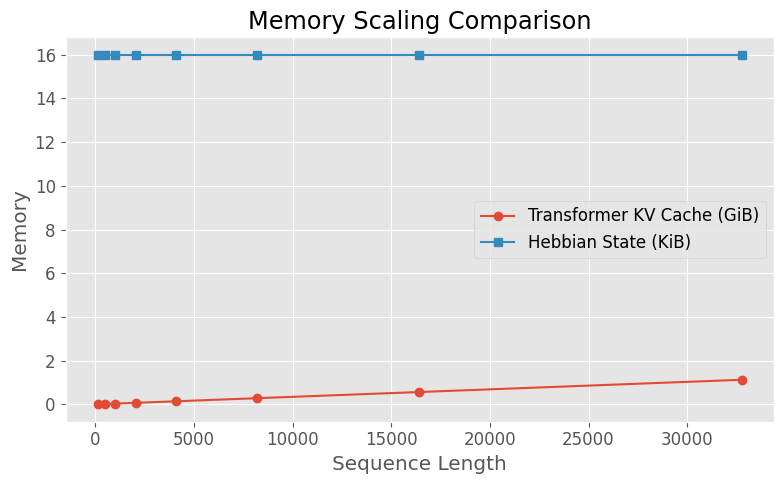

In [8]:
# ----------------------------------------------------
# Compare Memory Scaling
# ----------------------------------------------------

memory_curve = []

sequence_lengths = [
    128,
    512,
    1024,
    2048,
    4096,
    8192,
    16384,
    32768
]

for seq in sequence_lengths:

    stats = compare_memory(
        sequence_length=seq,
        hidden_size=768,
        n_layers=12,
        hebbian_model=memory
    )

    memory_curve.append(stats)

kv = [x["kv_gib"] for x in memory_curve]

hebb = [x["hebbian_kib"] for x in memory_curve]

plt.figure(figsize=(8,5))

plt.plot(
    sequence_lengths,
    kv,
    marker="o",
    label="Transformer KV Cache (GiB)"
)

plt.plot(
    sequence_lengths,
    hebb,
    marker="s",
    label="Hebbian State (KiB)"
)

plt.xlabel("Sequence Length")

plt.ylabel("Memory")

plt.title("Memory Scaling Comparison")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# Decay

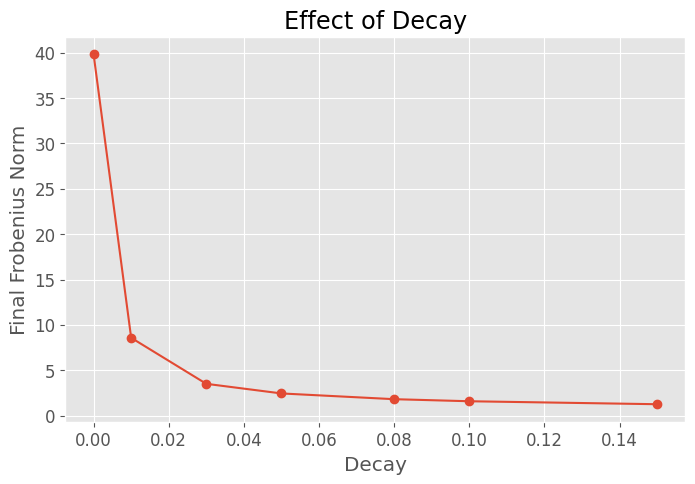

In [9]:
# ----------------------------------------------------
# Effect of Decay
# ----------------------------------------------------

decays = [0.00,0.01,0.03,0.05,0.08,0.10,0.15]

final_norms = []

for d in decays:

    cfg = HebbianConfig(
        n_neurons=64,
        decay=d,
        learning_rate=0.10,
        sparsity=0.10
    )

    sim = simulate_sequence(
        cfg,
        sim_cfg
    )

    final_norms.append(
        sim["norms"][-1]
    )

plt.figure(figsize=(8,5))

plt.plot(
    decays,
    final_norms,
    marker="o"
)

plt.xlabel("Decay")

plt.ylabel("Final Frobenius Norm")

plt.title("Effect of Decay")

plt.grid(True)

plt.show()

# Sparsity

# ----------------------------------------------------
# Effect of Sparsity
# ----------------------------------------------------

sparsities = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

density = []

for s in sparsities:

    cfg = HebbianConfig(
        n_neurons=64,
        decay=0.05,
        learning_rate=0.10,
        sparsity=s
    )

    sim = simulate_sequence(
        cfg,
        sim_cfg
    )

    matrix = np.array(
        sim["frames"][-1]["matrix"]
    )

    density.append(
        np.count_nonzero(matrix)/matrix.size
    )

plt.figure(figsize=(8,5))

plt.plot(
    sparsities,
    density,
    marker="o"
)

plt.xlabel("Activation Sparsity")

plt.ylabel("Matrix Density")

plt.title("Effect of Sparsity")

plt.grid(True)

plt.show()

In [10]:
# ----------------------------------------------------
# Complete Evaluation
# ----------------------------------------------------

results = full_evaluation()

for k,v in results.items():

    print("="*60)

    print(k.upper())

    print("="*60)

    print(v)

    print()

NORM_GROWTH
{'initial_norm': 0.9000000953674316, 'final_norm': 3.6967947483062744, 'maximum_norm': 3.7571959495544434, 'minimum_norm': 0.9000000953674316, 'mean_norm': 3.5010885316878557, 'std_norm': 0.3868556137023123}

SATURATION
{'saturated': np.False_, 'recent_std': 0.04327291943421291, 'recent_mean': 3.692640459537506}

WEIGHTS
{'max_weight': 0.6297363638877869, 'min_weight': -0.23774275183677673, 'mean_weight': 0.005279485613105997, 'std_weight': 0.057520642520517425, 'active_connections': 4056, 'density': 0.990234375}

MEMORY
{'memory_scaling_valid': True, 'results': [{'sequence_length': 128, 'kv_bytes': 4718592, 'kv_kib': 4608.0, 'kv_mib': 4.5, 'kv_gib': 0.00439453125, 'hebbian_bytes': 16384, 'hebbian_kib': 16.0, 'hebbian_norm': 0.0}, {'sequence_length': 512, 'kv_bytes': 18874368, 'kv_kib': 18432.0, 'kv_mib': 18.0, 'kv_gib': 0.017578125, 'hebbian_bytes': 16384, 'hebbian_kib': 16.0, 'hebbian_norm': 0.0}, {'sequence_length': 2048, 'kv_bytes': 75497472, 'kv_kib': 73728.0, 'kv_mib'

# Conclusions

## Observations

- The Hebbian memory maintains a **fixed-size synaptic matrix** throughout the simulation.
- Increasing the sequence length does **not** increase the allocated memory of the Hebbian state.
- Transformer KV-cache memory increases linearly with sequence length because every processed token contributes additional key/value vectors.
- The Frobenius norm initially increases as the synaptic matrix accumulates information and may stabilize depending on the decay parameter.
- Increasing activation sparsity changes the density and evolution of the synaptic weights.

---

# Limitations

This notebook is an educational demonstration.

It **does not implement the Brain Dragon Hatchling (BDH) architecture**.

Specifically:

- The Hebbian update rule used here is a simplified pedagogical proxy.
- The thermodynamic capacity bounds described in the BDH paper are **not** implemented.
- The synthetic token activations are randomly generated and do not correspond to real language model embeddings.
- The comparison focuses on memory behavior rather than language modeling performance.

The notebook is intended solely to build intuition for the difference between:

- **Growing KV-cache memory**
- **Fixed-size synaptic memory**